In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [2]:
!nvidia-smi

Sun Oct  4 02:03:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.2 MB/s eta 0:00:00


In [4]:
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.172


In [5]:
from google.colab import files

uploaded = files.upload()

Saving Object-Retrieval-Dataset-Small.zip to Object-Retrieval-Dataset-Small.zip


In [6]:
import zipfile
import os

zip_path = "/content/Object-Retrieval-Dataset-Small.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
import os

dataset_path = "/content/Object-Retrieval-Dataset-Small"

for folder, subfolders, files in os.walk(dataset_path):
    level = folder.replace(dataset_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(folder)}/")

    if level < 2:
        for file in files[:5]:
            print(f"{indent}  {file}")

Object-Retrieval-Dataset-Small/
  data.yaml
  images/
    train/
    val/
    test/
  labels/
    train/
    val/
    test/


In [8]:
from pathlib import Path

dataset_path = Path("/content/Object-Retrieval-Dataset-Small")

for split in ["train", "val", "test"]:
    image_dir = dataset_path / "images" / split
    label_dir = dataset_path / "labels" / split

    images = [
        f for f in image_dir.iterdir()
        if f.is_file()
    ]

    labels = [
        f for f in label_dir.iterdir()
        if f.suffix.lower() == ".txt"
    ]

    print(f"{split.upper()}:")
    print(f"  Images : {len(images)}")
    print(f"  Labels : {len(labels)}")
    print()

TRAIN:
  Images : 1200
  Labels : 1200

VAL:
  Images : 150
  Labels : 150

TEST:
  Images : 150
  Labels : 150



In [9]:
from pathlib import Path

yaml_path = Path("/content/Object-Retrieval-Dataset-Small/data.yaml")

print(yaml_path.read_text())

train: images/train
val: images/val
test: images/test

nc: 3

names:
  0: Pen
  1: Spectacles
  2: Keys



In [10]:
from pathlib import Path

dataset_path = Path("/content/Object-Retrieval-Dataset-Small")

valid_classes = {0, 1, 2}
invalid_labels = []

for split in ["train", "val", "test"]:
    label_dir = dataset_path / "labels" / split

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line_number, line in enumerate(f, start=1):
                parts = line.strip().split()

                if not parts:
                    continue

                try:
                    class_id = int(parts[0])

                    if class_id not in valid_classes:
                        invalid_labels.append(
                            (label_file.name, line_number, class_id)
                        )

                except ValueError:
                    invalid_labels.append(
                        (label_file.name, line_number, "invalid")
                    )

print("Invalid labels:", len(invalid_labels))

if len(invalid_labels) == 0:
    print("✅ All class IDs are valid: 0, 1, 2")
else:
    print("⚠️ Invalid labels found:")
    print(invalid_labels[:10])

Invalid labels: 0
✅ All class IDs are valid: 0, 1, 2


In [11]:
from ultralytics import YOLO

# Load pretrained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data="/content/Object-Retrieval-Dataset-Small/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/object_retrieval_training",
    name="yolov8n_pen_spectacles_keys"
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Object-Retrieval-Dataset-Small/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_pen_spectacles_keys, nbs=64, nm

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/object_retrieval_training/yolov8n_pen_spectacles_keys/weights/best.pt"
)

print("Model loaded successfully!")
print("Classes:", model.names)

Model loaded successfully!
Classes: {0: 'Pen', 1: 'Spectacles', 2: 'Keys'}


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/object_retrieval_training/yolov8n_pen_spectacles_keys/weights/best.pt"
)

results = model.predict(
    source="/content/Object-Retrieval-Dataset-Small/images/test",
    conf=0.5,
    save=True
)

print("Testing completed!")


image 1/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0001.jpg: 448x640 1 Keys, 8.9ms
image 2/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0002.jpg: 448x640 1 Keys, 9.9ms
image 3/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0003.jpg: 448x640 1 Keys, 9.0ms
image 4/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0004.jpg: 448x640 1 Keys, 9.6ms
image 5/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0005.jpg: 448x640 3 Keyss, 10.5ms
image 6/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0006.jpg: 480x640 1 Keys, 35.8ms
image 7/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0007.jpg: 448x640 1 Keys, 9.9ms
image 8/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0008.jpg: 416x640 1 Keys, 46.0ms
image 9/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0009.jpg: 480x640 1 Keys, 11.6ms
image 10/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0010.jpg: 480x6

In [12]:
from IPython.display import display
from PIL import Image
import glob
import os

result_images = glob.glob(
    "/content/object_retrieval_training/yolov8n_pen_spectacles_keys/test*/*.jpg"
)

print("Number of result images:", len(result_images))

if result_images:
    display(Image.open(result_images[0]))

Number of result images: 0


In [13]:
import os

base = "/content"

for root, dirs, files in os.walk(base):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files and "Object-Retrieval-Dataset-Small" not in root:
        print(root, "→", len(image_files), "images")

/content/object_retrieval_training/yolov8n_pen_spectacles_keys → 20 images



image 1/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0001.jpg: 448x640 1 Keys, 10.0ms
image 2/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0002.jpg: 448x640 1 Keys, 10.6ms
image 3/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0003.jpg: 448x640 1 Keys, 10.4ms
image 4/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0004.jpg: 448x640 1 Keys, 14.2ms
image 5/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0005.jpg: 448x640 3 Keyss, 8.9ms
image 6/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0006.jpg: 480x640 1 Keys, 50.3ms
image 7/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0007.jpg: 448x640 1 Keys, 10.6ms
image 8/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0008.jpg: 416x640 1 Keys, 49.2ms
image 9/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0009.jpg: 480x640 1 Keys, 10.8ms
image 10/150 /content/Object-Retrieval-Dataset-Small/images/test/keys_0010.jpg: 4

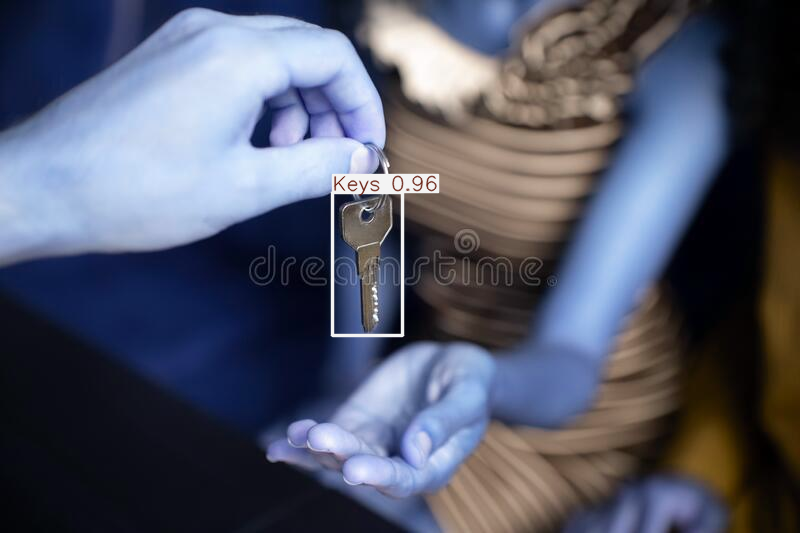

In [14]:
from IPython.display import display
from PIL import Image
import numpy as np

# Take the first test image
test_image = "/content/Object-Retrieval-Dataset-Small/images/test"

results = model.predict(
    source=test_image,
    conf=0.5,
    save=True
)

# Display first prediction
annotated = results[0].plot()

display(Image.fromarray(annotated))

Prediction images found: 150
keys_0002.jpg


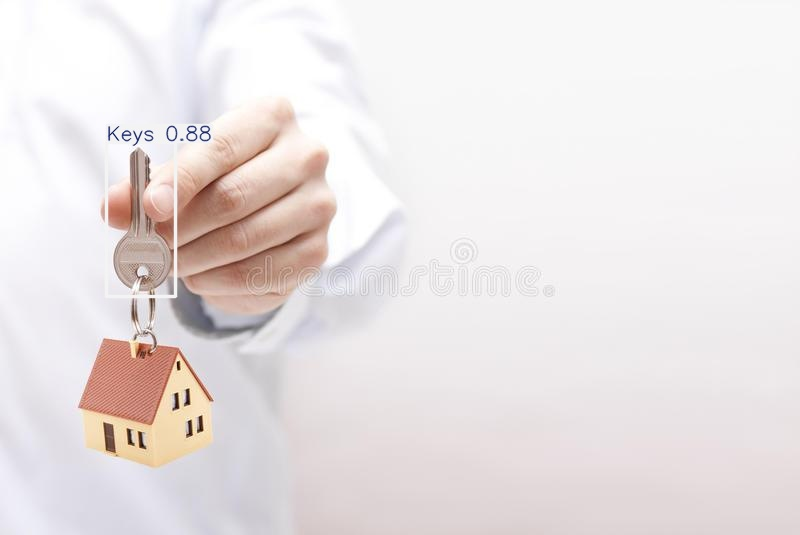

pen_0027.jpg


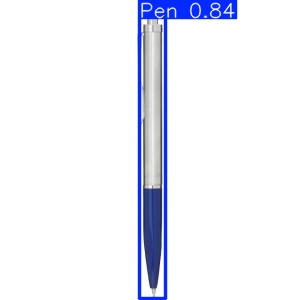

keys_0010.jpg


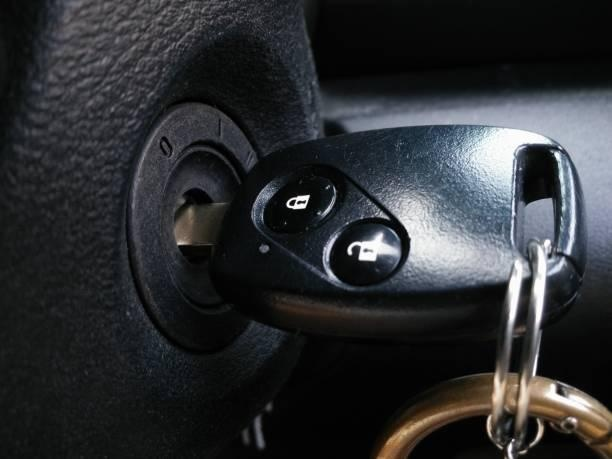

pen_0022.jpg


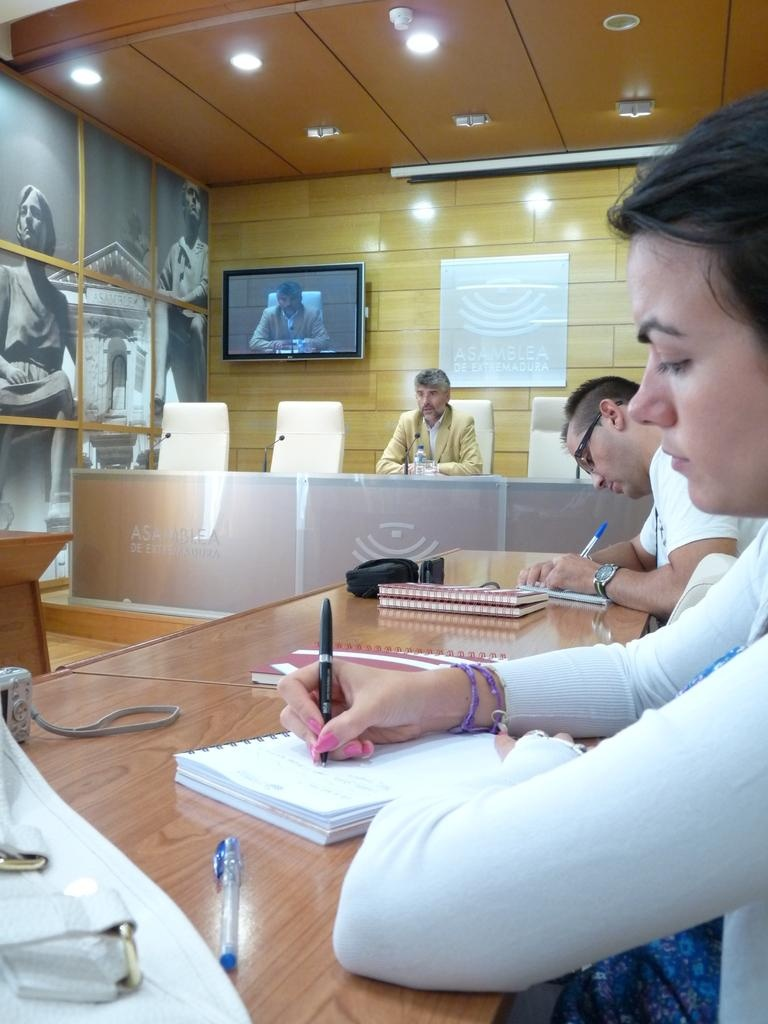

pen_0039.jpg


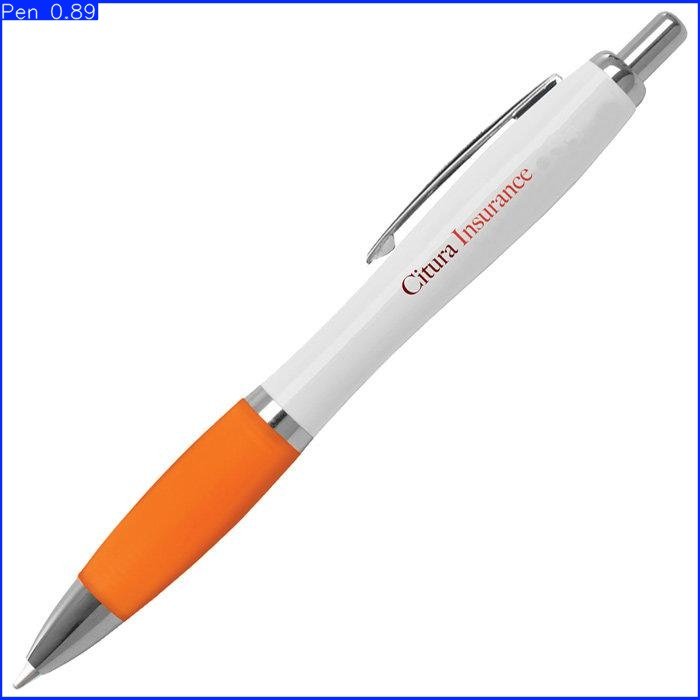

pen_0030.jpg


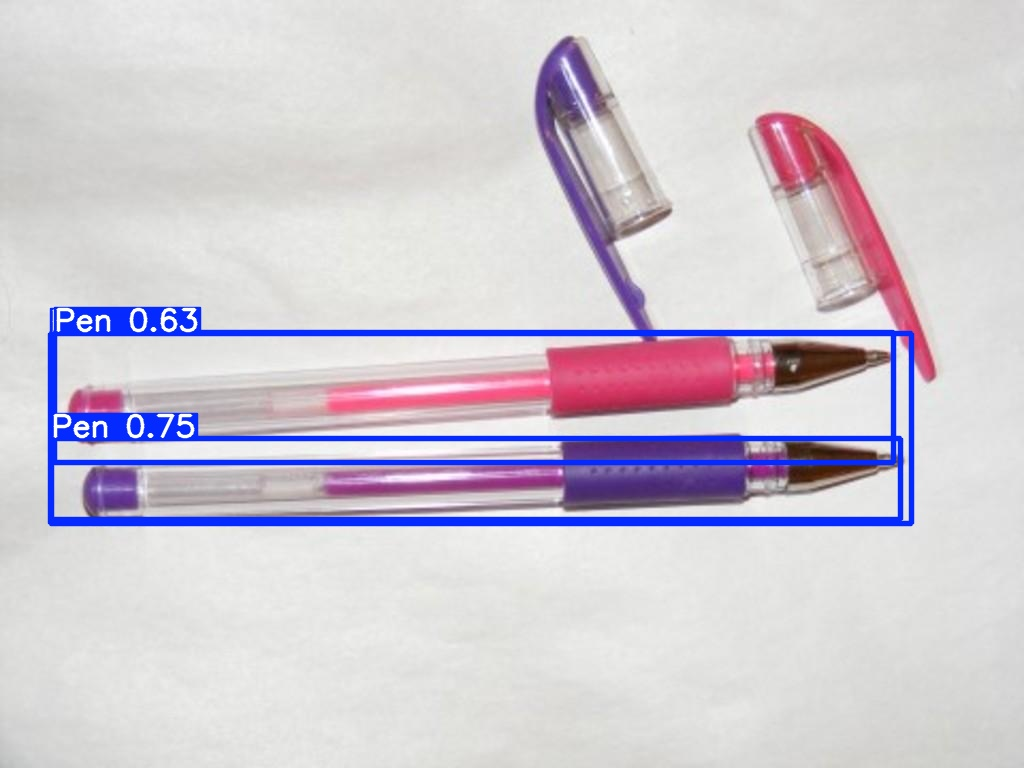

In [15]:
from IPython.display import display
from PIL import Image
import glob
import random
import os

result_path = "/content/runs/detect/predict"

images = glob.glob(result_path + "/*.jpg") + \
         glob.glob(result_path + "/*.png") + \
         glob.glob(result_path + "/*.jpeg")

print("Prediction images found:", len(images))

# Display 6 random prediction results
for img_path in random.sample(images, min(6, len(images))):
    print(os.path.basename(img_path))
    display(Image.open(img_path))

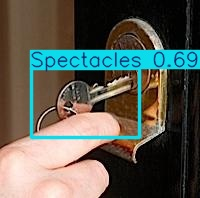

In [16]:
img_path = "/content/runs/detect/predict/keys_0039.jpg"

display(Image.open(img_path))

In [17]:
from ultralytics import YOLO

model = YOLO(
    "/content/object_retrieval_training/yolov8n_pen_spectacles_keys/weights/best.pt"
)

# Evaluate on the TEST set
test_results = model.val(
    data="/content/Object-Retrieval-Dataset-Small/data.yaml",
    split="test",
    imgsz=640,
    device=0
)

print("Test evaluation completed.")

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 962.4±338.9 MB/s, size: 36.9 KB)
val: Scanning /content/Object-Retrieval-Dataset-Small/labels/test... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 1.9Kit/s 0.1s
val: New cache created: /content/Object-Retrieval-Dataset-Small/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.3it/s 3.0s
                   all        150        217      0.802      0.799      0.825      0.511
                   Pen         50         84      0.695      0.726      0.708      0.411
            Spectacles         50         81      0.909      0.901       0.93      0.577
                  Keys         50         52        0.8       0.77      0.837      0.546
Speed: 2.4ms preprocess, 6.3ms inference,

In [18]:
import os

print(os.listdir("/content/runs/detect/val"))

['BoxP_curve.png', 'val_batch1_pred.jpg', 'confusion_matrix.png', 'val_batch2_pred.jpg', 'BoxF1_curve.png', 'val_batch1_labels.jpg', 'BoxPR_curve.png', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch2_labels.jpg', 'confusion_matrix_normalized.png', 'BoxR_curve.png']


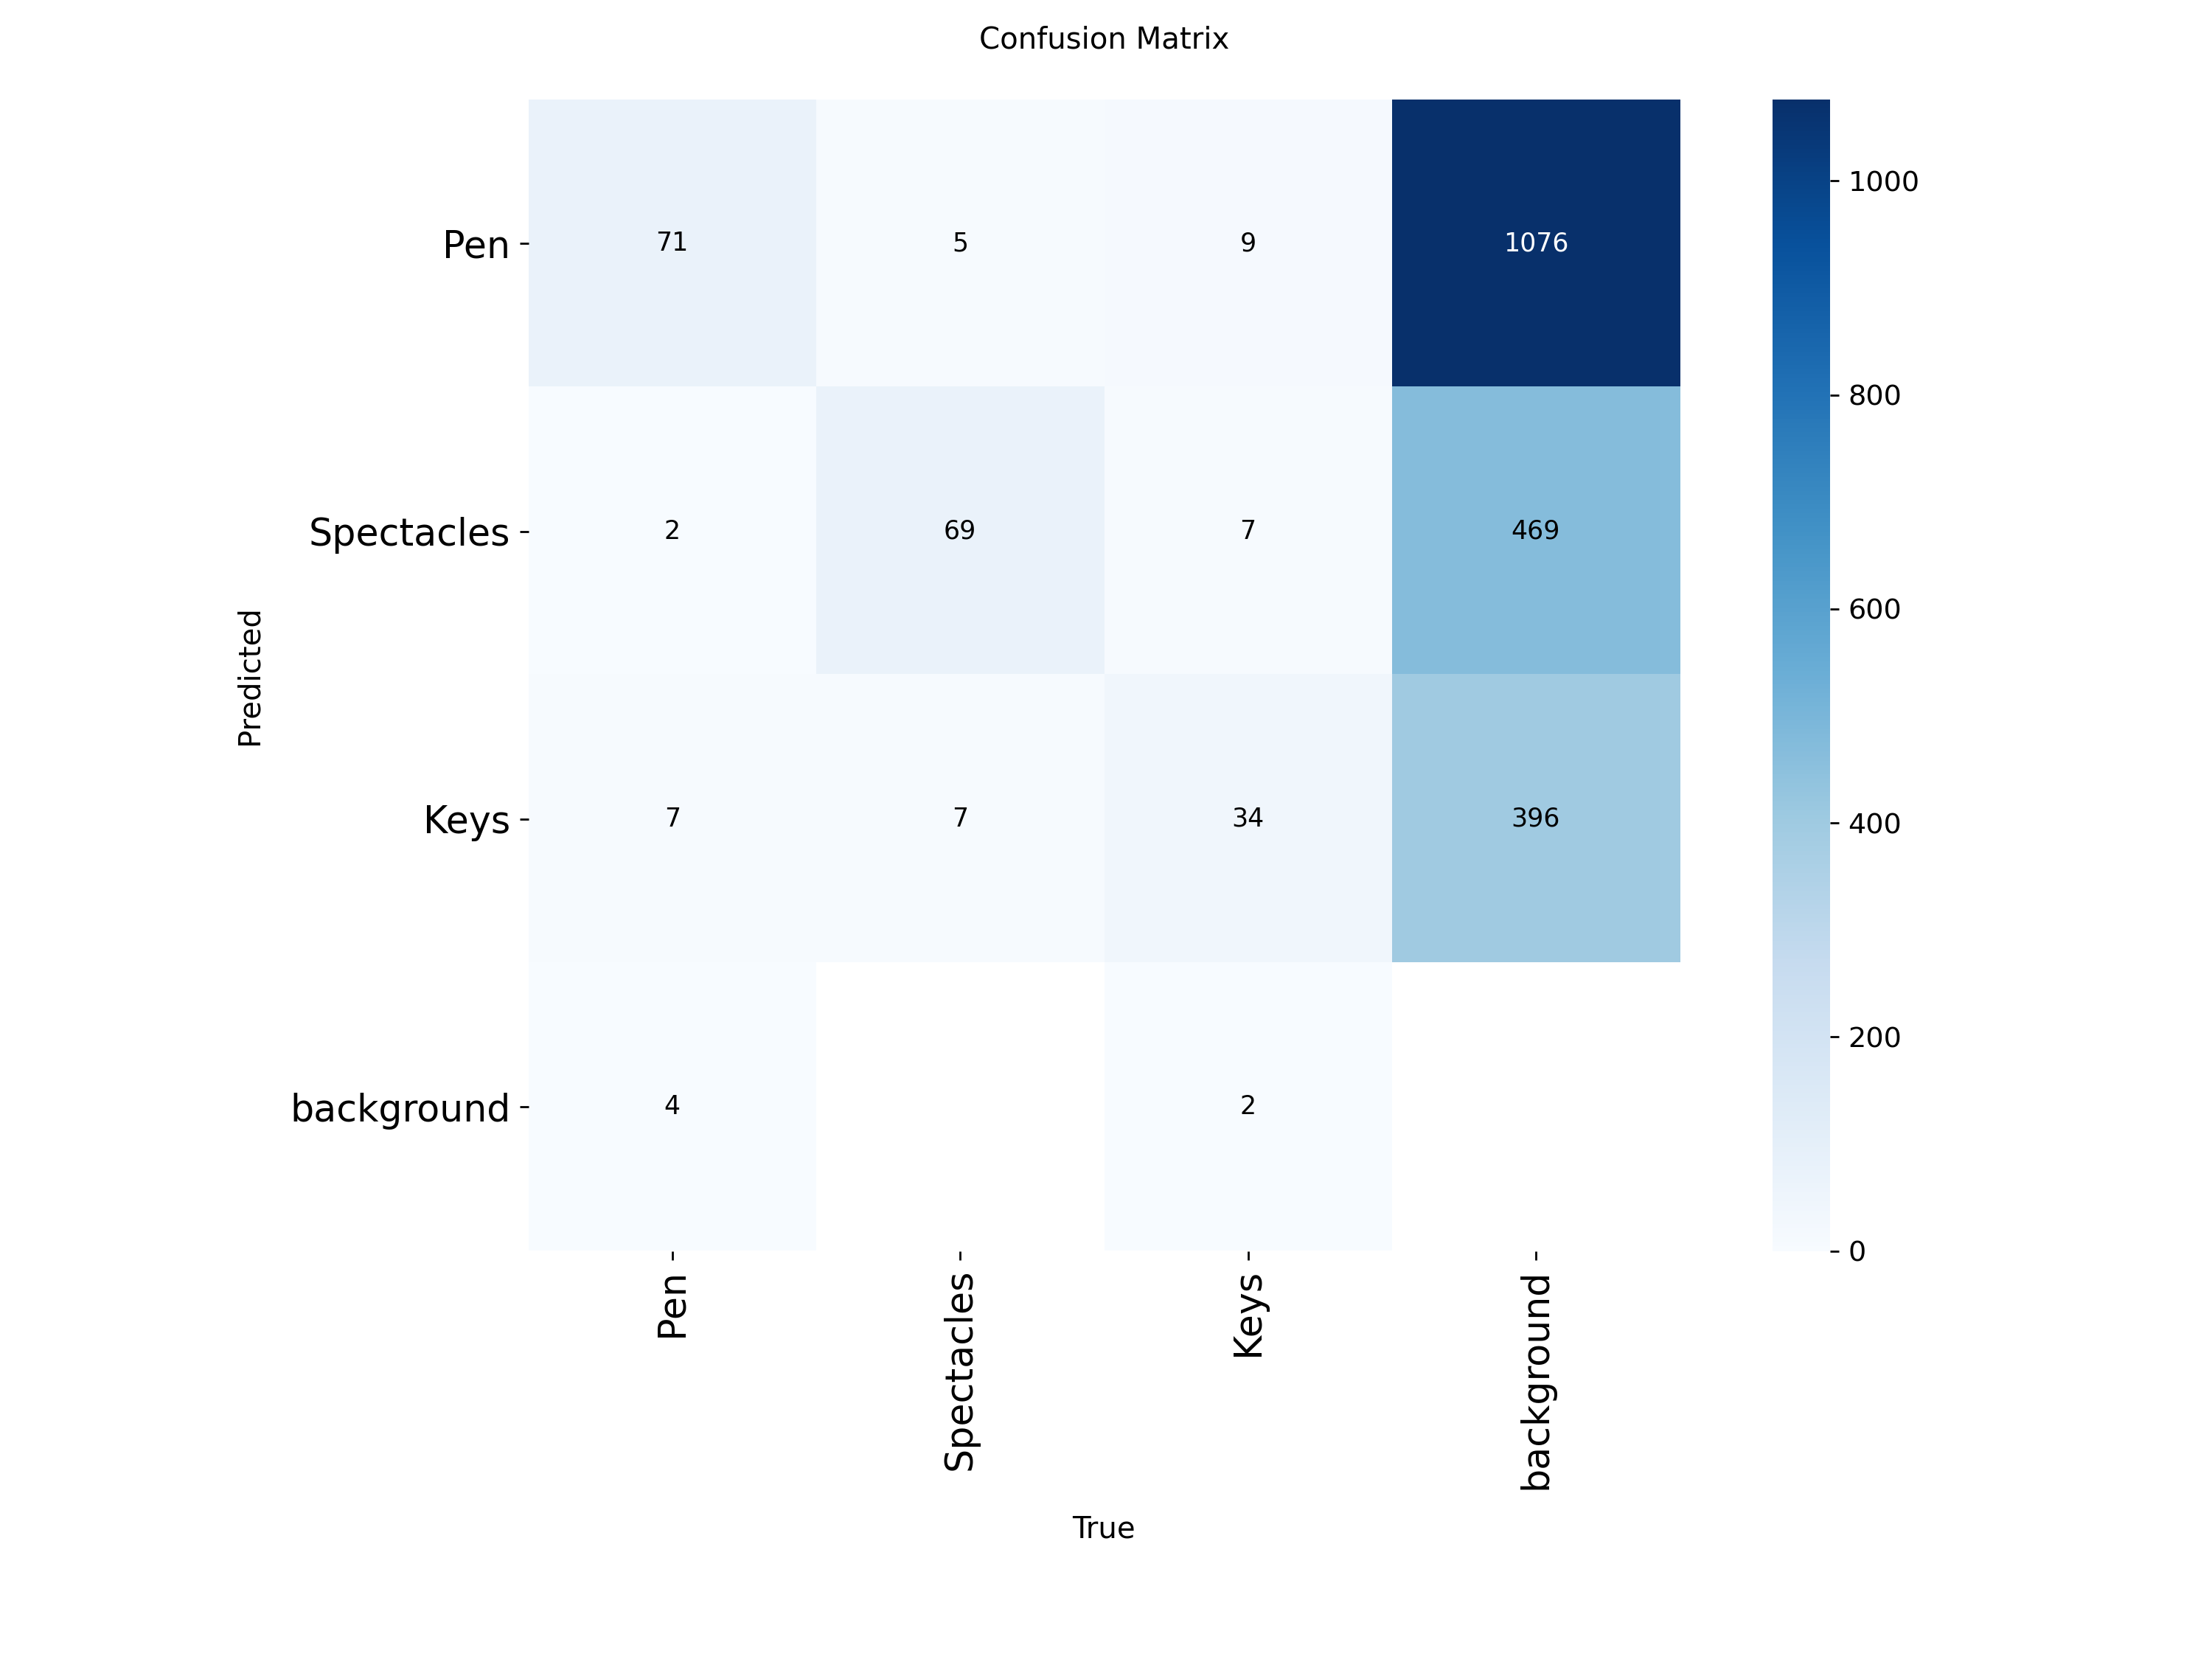

In [19]:
from IPython.display import display
from PIL import Image

img = Image.open("/content/runs/detect/val/confusion_matrix.png")
display(img)

In [20]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)


Saving Screenshot 2026-10-02 211838.png to Screenshot 2026-10-02 211838.png
Uploaded files:
Screenshot 2026-10-02 211838.png


In [21]:
from ultralytics import YOLO

model = YOLO(
    "/content/object_retrieval_training/yolov8n_pen_spectacles_keys/weights/best.pt"
)

print("Model loaded!")
print("Classes:", model.names)

Model loaded!
Classes: {0: 'Pen', 1: 'Spectacles', 2: 'Keys'}



Testing: Screenshot 2026-10-02 211838.png


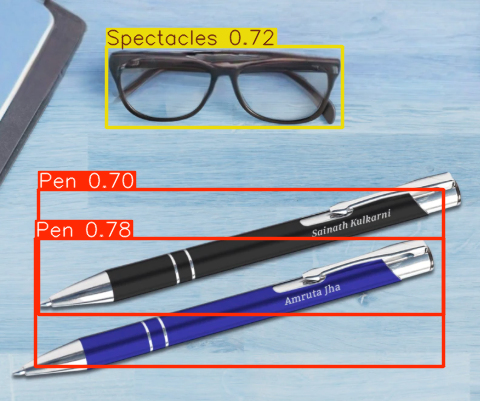

In [22]:
from PIL import Image
from IPython.display import display
import os

for filename in uploaded.keys():

    print("\n" + "="*60)
    print("Testing:", filename)

    results = model.predict(
        source="/content/" + filename,
        conf=0.5,
        verbose=False
    )

    # Display the image with YOLO predictions
    annotated = results[0].plot()

    display(Image.fromarray(annotated))

In [23]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving Screenshot 2026-10-02 212914.png to Screenshot 2026-10-02 212914.png
Uploaded files:
Screenshot 2026-10-02 212914.png


In [24]:
from ultralytics import YOLO

model = YOLO(
    "/content/object_retrieval_training/yolov8n_pen_spectacles_keys/weights/best.pt"
)

print("Model loaded!")
print("Classes:", model.names)

Model loaded!
Classes: {0: 'Pen', 1: 'Spectacles', 2: 'Keys'}



Testing: Screenshot 2026-10-02 212914.png


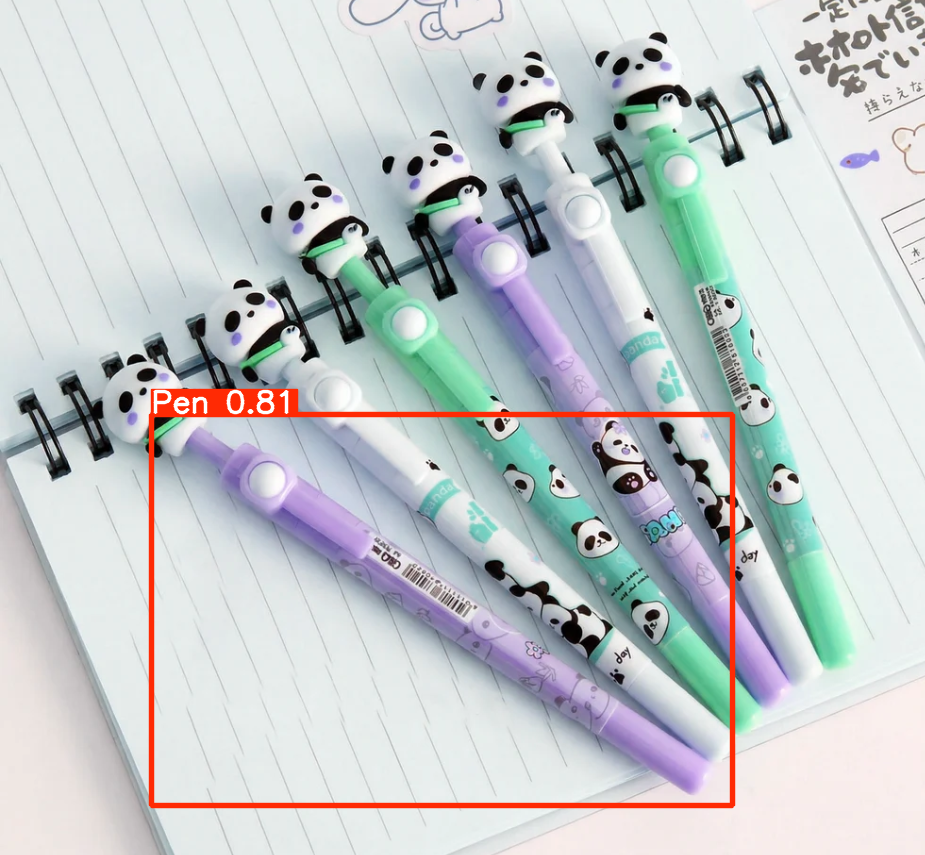

In [25]:
from PIL import Image
from IPython.display import display
import os

for filename in uploaded.keys():

    print("\n" + "="*60)
    print("Testing:", filename)

    results = model.predict(
        source="/content/" + filename,
        conf=0.5,
        verbose=False
    )

    # Display the image with YOLO predictions
    annotated = results[0].plot()

    display(Image.fromarray(annotated))

In [32]:
from google.colab import files

uploaded = files.upload()


Saving Screenshot 2026-10-02 215323.png to Screenshot 2026-10-02 215323.png



Testing: Screenshot 2026-10-02 215323.png


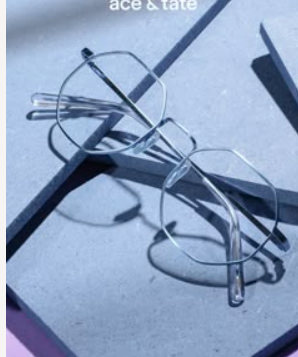

In [33]:
from PIL import Image
from IPython.display import display
import os

for filename in uploaded.keys():

    print("\n" + "="*60)
    print("Testing:", filename)

    results = model.predict(
        source="/content/" + filename,
        conf=0.5,
        verbose=False
    )

    # Display the image with YOLO predictions
    annotated = results[0].plot()

    display(Image.fromarray(annotated))

In [28]:
from google.colab import files

uploaded = files.upload()


Saving Screenshot 2026-10-02 213836.png to Screenshot 2026-10-02 213836.png



Testing: Screenshot 2026-10-02 213836.png


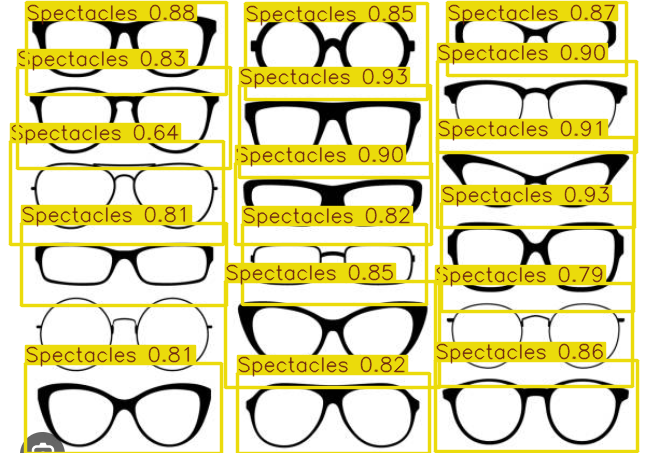

In [29]:
from PIL import Image
from IPython.display import display
import os

for filename in uploaded.keys():

    print("\n" + "="*60)
    print("Testing:", filename)

    results = model.predict(
        source="/content/" + filename,
        conf=0.5,
        verbose=False
    )

    # Display the image with YOLO predictions
    annotated = results[0].plot()

    display(Image.fromarray(annotated))

In [34]:
from google.colab import files

files.download(
    "/content/object_retrieval_training/yolov8n_pen_spectacles_keys/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
from google.colab import files

files.download(
    "/content/Object-Retrieval-Dataset-Small/data.yaml"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>